# Understanding the Gaussian Mixture Model (GMM)

### The Building Block: The Normal Distribution
At its core, a GMM is a collection of **Normal (Gaussian) Distributions**.

Let's use the example of **Human Heights**. If we measure the heights of a population, the data forms a "Bell Curve." We define $G(x)$ as the function that gives us the **probability density** (the likelihood) of a specific height $x$.

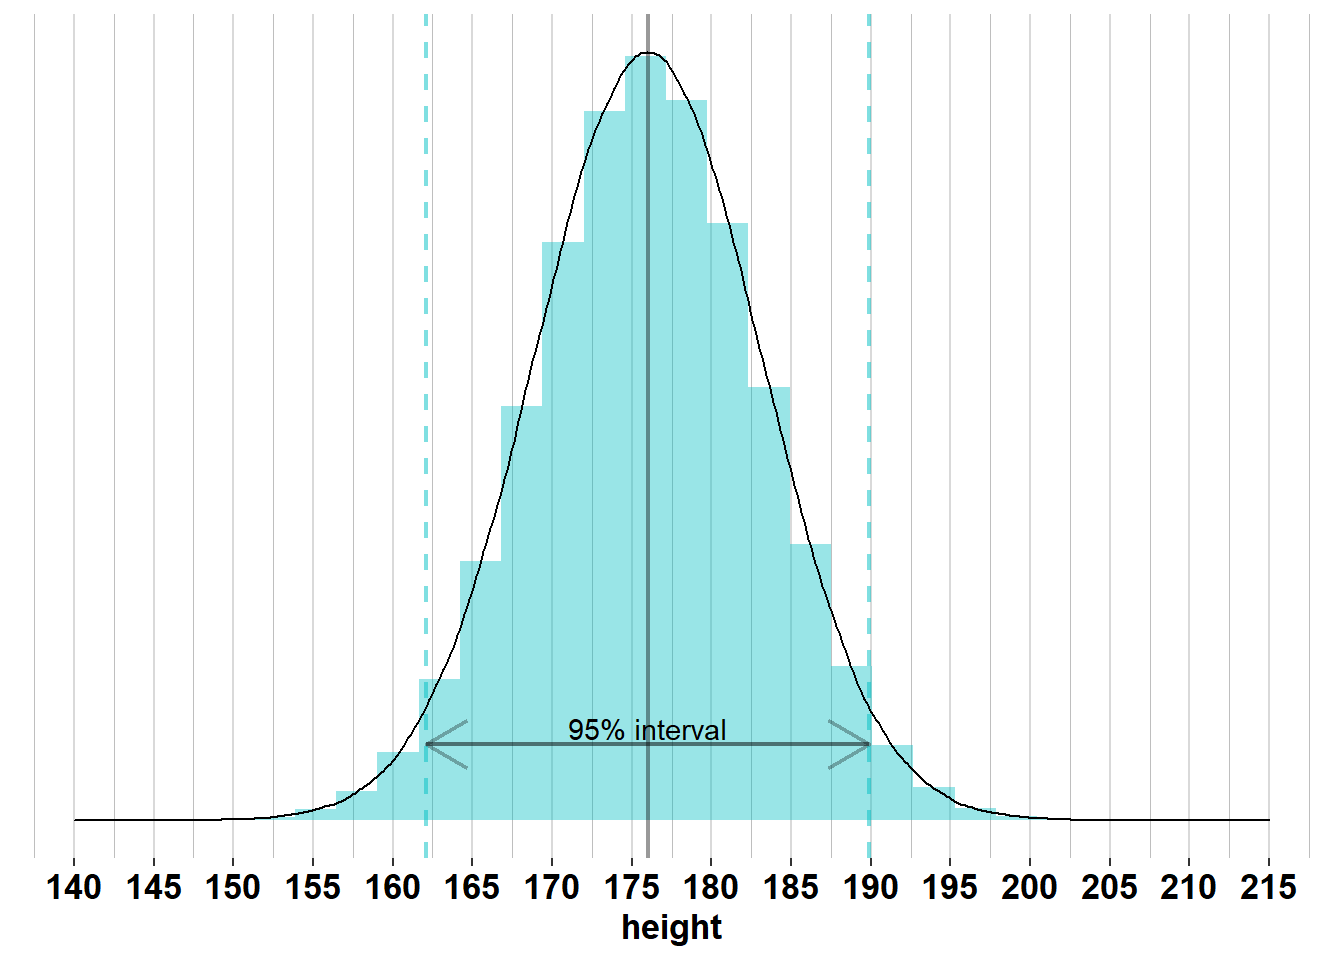

#### How to interpret $G(x)$:
* **The Peak (The Average):** If the average height is **177cm**, then $G(177)$ returns the highest value. Most people you pick at random will be near this height.
* **The Tails (The Extremes):** A height of **200cm** is rare. Therefore, $G(200)$ returns a very small value.

**The Math:**
$$G(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{ -\frac{(x - \mu)^2}{2\sigma^2} }$$

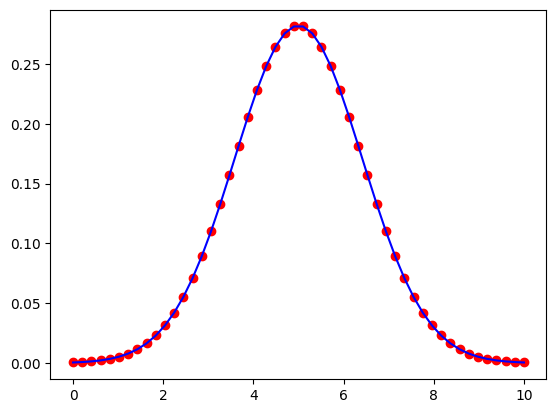

In [17]:
'''
Plotting a Gaussian Example

In this inference example, you’ll notice that the probability of a value being
around 5 is very high.You could even say that choosing 5 as your
prediction results in the least amount of error across all cases.

For instance, if you pick 3 while the true center is 5,
you have an error of 2 units. If you pick 7 and the actual
data point is further away, the error increases. Because a Gaussian
curve is symmetric, the center (mean) effectively splits the data in half.
Choosing this central point ensures that, on average, the total error remains
as small as possible.
'''
import numpy as np
import matplotlib.pyplot as plt

def Nvalue(x, mean, variance):
    sd = np.sqrt(variance)
    exponent = np.exp(-((x - mean) ** 2) / (2 * (variance + 1e-10)))
    return (1 / (sd * np.sqrt(2 * np.pi) + 1e-10)) * exponent

x = np.linspace(0, 10, 50)
y = Nvalue(x, 5, 2)

plt.plot(x, y, c="b")
plt.scatter(x, y, c="r")
plt.show()


### From One Gaussian to a "Mixture"

What if our data doesn't fit a single bell curve? Imagine a dataset containing two different groups (e.g., the heights of both males and females). In this case, we would observe **two distinct peaks** (a bimodal distribution).

A **Gaussian Mixture Model (GMM)** solves this by summing multiple Gaussians:

$$\text{Total Probability} = \sum_{k=1}^{K} \pi_k \mathcal{N}(x \mid \mu_k, \sigma_k^2)$$

Where $\pi_k$ is the **Weight** (the percentage of the population belonging to that specific group).

### Step 1: Initialization

To begin, we must initialize the parameters for our $K$ Gaussians. Common strategies include:

* **Weights ($\pi$):** Usually initialized equally as $1/K$.
* **Means ($\mu$):** Assigned random values from the data or initialized more intelligently using **K-Means++**.
* **Variances ($\sigma^2$):** Often initialized to the overall variance of the entire dataset.

### Step 2: The Expectation Step (E-Step)

Once initialized, we calculate the probability of a specific data point $x$ belonging to each distribution. This is known as calculating the **"responsibilities."**

For example, given a point $x$, we calculate:
1.  **Probability in Distribution 1:** (e.g., where $\mu = 32.5$ and $\sigma^2 = 5.0$).
2.  **Probability in Distribution 2:** (calculated using its respective $\mu$ and $\sigma^2$).

By comparing these probabilities, the model estimates which Gaussian "generated" that data point.

In [33]:
'''
example with 3 Gaussians
'''
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
np.random.seed(42)
cluster1 = np.random.normal(loc=2.0, scale=0.5, size=100)
cluster2 = np.random.normal(loc=7.0, scale=1.0, size=150)
cluster3 = np.random.normal(loc=12.0, scale=0.8, size=120)

points = np.concatenate([cluster1, cluster2, cluster3])
np.random.shuffle(points)

#random inits
weights = [1/3, 1/3, 1/3]
means = [1.0, 7.0, 15.0]
vars = [np.var(points)] * 3

def Nvalue(x, mean, variance):
    sd = np.sqrt(variance)
    # 1e-10 prevents division by zero
    exponent = np.exp(-((x - mean) ** 2) / (2 * (variance + 1e-10)))
    return (1 / (sd * np.sqrt(2 * np.pi) + 1e-10)) * exponent

def estep(data, means, vars, weights):
    # Probability of data point x belonging to each Gaussian
    r1 = weights[0] * Nvalue(data, means[0], vars[0])
    r2 = weights[1] * Nvalue(data, means[1], vars[1])
    r3 = weights[2] * Nvalue(data, means[2], vars[2])

    total = r1 + r2 + r3 + 1e-10
    # Add epsilon to avoid div by zero
    return r1 / total, r2 / total, r3 / total

### Step 3: Updating the Gaussians (The M-Step)

Now that we know how likely each point belongs to each distribution (the "responsibilities"), we need to update our Gaussians to better fit the data. This is called the **Maximization Step**.

<br>

##### The Intuition: "The Tug-of-War"
Think of it as a tug-of-war. If you have values `5, 5, 35`, the mean is `15`. But if the values are `5, 4, 3`, the mean is `4`. Every value "pulls" the mean toward itself.

In a GMM, we don't treat every point equally. Instead:
* A point with a **high probability** ($r_{ik}$) of belonging to a distribution pulls that mean strongly toward it.
* A point with a **low probability** barely moves the mean at all.


<br>

#### 1. Updating the Mean ($\mu$)
The new mean is a **weighted average**. We multiply each point by its responsibility and divide by the total responsibility for that Gaussian:

$$\mu_k = \frac{\sum r_{ik} x_i}{\sum r_{ik}}$$
<br>

#### 2. Updating the Variance ($\sigma^2$)
Similarly, the variance is updated by calculating the weighted average of the squared distances from the *new* mean:

$$\sigma_k^2 = \frac{\sum r_{ik} (x_i - \mu_k)^2}{\sum r_{ik}}$$
<br>
#### 3. Updating the Weights ($\pi$)
Finally, we update the weight of the Gaussian. If a Gaussian "owns" a lot of points, its weight increases:

$$\pi_k = \frac{\text{Sum of Responsibilities for Cluster } k}{\text{Total Number of Points}}$$



In [34]:
#As same as the formula's
def mstep(data, resp):
    Nk = np.sum(resp)
    new_mean = np.sum(resp * data) / Nk
    new_var = np.sum(resp * (data - new_mean)**2) / Nk
    new_weight = Nk / len(data)
    return new_mean, new_var, new_weight

In [35]:
#Then we run a loop and update the values at each iteration based on the e and mstep
iterations = 100
for i in range(iterations):
    # E-step: calculate responsibilities using 'points'
    resps = estep(points, means, vars, weights)

    # M-step: update parameters for each cluster
    for k in range(3):
        means[k], vars[k], weights[k] = mstep(points, resps[k])

    if i % 25 == 0:
        print(f"Iteration {i}: Means = {np.round(means, 2)}")

Iteration 0: Means = [ 3.67  7.38 11.31]
Iteration 25: Means = [ 1.95  7.05 12.03]
Iteration 50: Means = [ 1.95  7.05 12.03]
Iteration 75: Means = [ 1.95  7.05 12.03]


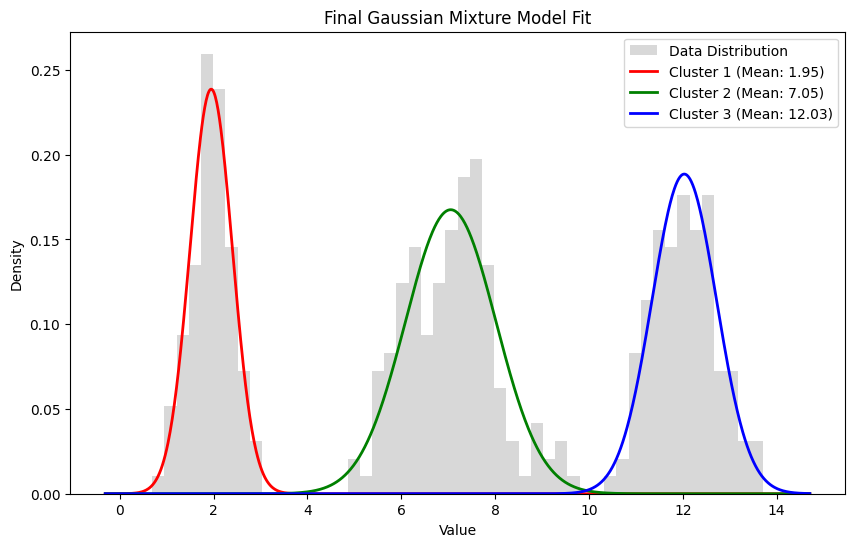

In [36]:
xaxis = np.linspace(min(points)-1, max(points)+1, 1000)
plt.figure(figsize=(10, 6))

# Plot Histogram of Data
plt.hist(points, bins=50, density=True, alpha=0.3, color='gray', label="Data Distribution")

# Plot the individual Gaussians
colors = ['r', 'g', 'b']
for k in range(3):
    y_plot = weights[k] * Nvalue(xaxis, means[k], vars[k])
    plt.plot(xaxis, y_plot, color=colors[k], lw=2, label=f"Cluster {k+1} (Mean: {means[k]:.2f})")

plt.title("Final Gaussian Mixture Model Fit")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()